In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap

In [3]:
Total_hist_model = xr.open_dataset('pH_Modeluncertainty_hist.nc').squeeze()
Total_585_model = xr.open_dataset('pH_Modeluncertainty_ssp585.nc').squeeze()
Total_245_model = xr.open_dataset('pH_Modeluncertainty_ssp245.nc').squeeze()
Total_126_model = xr.open_dataset('pH_Modeluncertainty_ssp126.nc').squeeze()

Total_hist_intern = xr.open_dataset('UIN_STL_hist_pH.nc').squeeze()
Total_585_intern = xr.open_dataset('UIN_STL_std_ssp585_pH.nc').squeeze()
Total_245_intern = xr.open_dataset('UIN_STL_SSP245_pH.nc').squeeze()
Total_126_intern = xr.open_dataset('UIN_STL_std_SSP126_pH.nc').squeeze()

Total_hist = xr.open_dataset('TU_ssp126_pH_r1.nc').squeeze()
Total_585 = xr.open_dataset('TU_ssp585_pH_r1.nc').squeeze()
Total_245 = xr.open_dataset('TU_ssp245_pH_r1.nc').squeeze()
Total_126 = xr.open_dataset('TU_ssp126_pH_r1.nc').squeeze()


Total_hist_intern = Total_hist_intern.rename({"internal_variability": "ph"})
Total_585_intern = Total_585_intern.rename({"internal_variability": "ph"})

Total_245_intern = Total_245_intern.rename({"internal_variability": "ph"})

Total_126_intern = Total_126_intern.rename({"internal_variability": "ph"})


lat_range = slice(-30, 30)  
lon_range = slice(30, 120)  

Total_hist_model  = Total_hist_model.sel(lat=lat_range, lon=lon_range)
Total_585_model = Total_585_model.sel(lat=lat_range, lon=lon_range)
Total_245_model = Total_245_model.sel(lat=lat_range, lon=lon_range)
Total_126_model = Total_126_model.sel(lat=lat_range, lon=lon_range)

Total_hist_intern  = Total_hist_intern.sel(lat=lat_range, lon=lon_range)
Total_585_intern = Total_585_intern.sel(lat=lat_range, lon=lon_range)
Total_245_intern = Total_245_intern.sel(lat=lat_range, lon=lon_range)
Total_126_intern = Total_126_intern.sel(lat=lat_range, lon=lon_range)

Total_hist  = Total_hist.sel(lat=lat_range, lon=lon_range)
Total_585 = Total_585.sel(lat=lat_range, lon=lon_range)
Total_245 = Total_245.sel(lat=lat_range, lon=lon_range)
Total_126 = Total_126.sel(lat=lat_range, lon=lon_range)




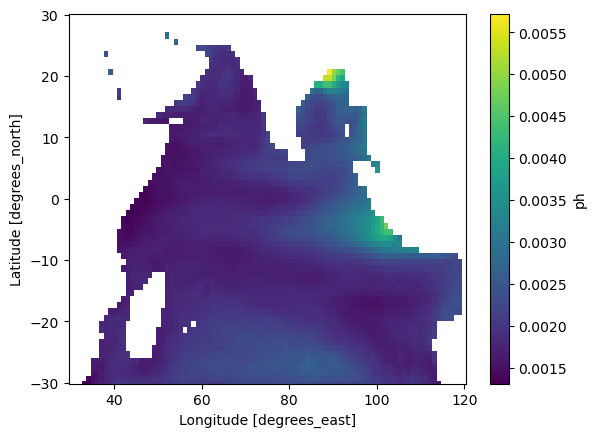

In [4]:
Total_126_intern.ph.plot()

/tmp/ipykernel_23483/595912830.py:48: UserWarning: The following kwargs were not used by contour: 'robust'
  quad_contour_set = m.contourf(lon, lat, ph_data, levels=levels, cmap=cmap2, extend='both', zorder=10, robust='TRUE')


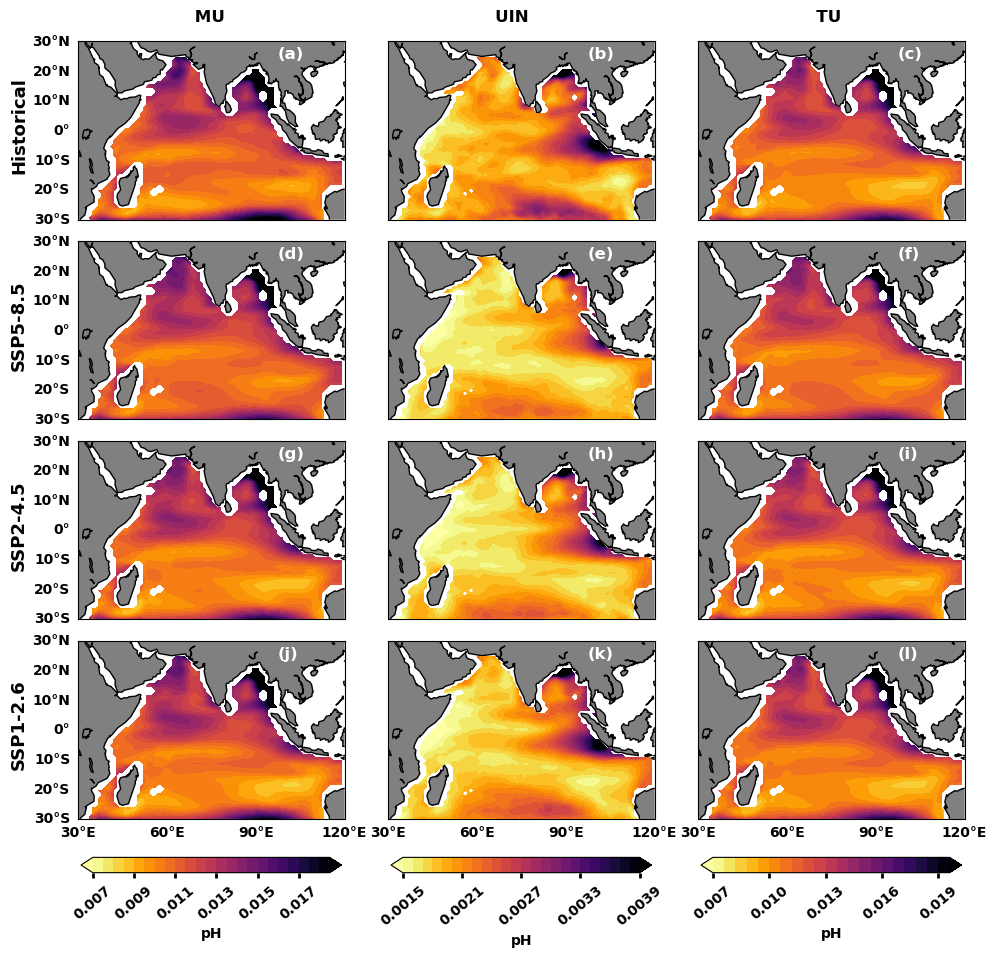

In [13]:
fig, ax = plt.subplots(nrows=4, ncols=3, sharex=True, sharey=True, figsize=(20, 16))
plt.subplots_adjust(bottom=0.2, top=0.8, left=0.13, right=0.75, wspace=-0.5, hspace=0.12)
fig.suptitle(' MU                                               UIN                                                  TU', 
             fontsize=12, ha='center', fontweight='bold', x=0.437, y=0.82)

periods = ['Historical', 'SSP5-8.5', 'SSP2-4.5', 'SSP1-2.6']
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
datasets = {
    'model': [Total_hist_model, Total_585_model, Total_245_model, Total_126_model],
    'intern': [Total_hist_intern, Total_585_intern, Total_245_intern, Total_126_intern],
    'total': [Total_hist, Total_585, Total_245, Total_126]
}

quad_contour_sets_model = []
quad_contour_sets_uncertainty = []

for i, period in enumerate(periods):
    for j, (key, data_list) in enumerate(datasets.items()):
        data = data_list[i]
        ph_data = np.squeeze(data.ph)

        if key == 'model':
            levels = np.arange(0.007, 0.019, 0.0005)
            cmap1 = 'inferno_r'
            norm = None
            
        elif key == 'intern':
#             norm = norm_ph
#             levels = l7_ph
            cmap2 = 'inferno_r'
            levels = np.arange(0.0015, 0.004, 0.0001)
            norm = None
        else:  # 'total'
#             norm = norm_diff
            cmap2 = 'inferno_r'
#             levels = l6_diff
            norm = None
            levels = np.arange(0.007, 0.020, 0.0006)
    
    
       
        m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[i, j])
        m.drawcoastlines()
        m.fillcontinents(color='gray', lake_color='gray')

        lon, lat = np.meshgrid(data.lon, data.lat)
        if key in ['intern', 'total']:
            quad_contour_set = m.contourf(lon, lat, ph_data, levels=levels, cmap=cmap2, extend='both', zorder=10, robust='TRUE')
            quad_contour_sets_model.append(quad_contour_set)
        else:
#             quad_contour_set = m.pcolormesh(lon, lat, ph_data, norm=norm, cmap=cmap, shading='gouraud', zorder=10)
 
              quad_contour_set = m.contourf(lon, lat, ph_data, levels=levels, cmap=cmap1, extend='both', zorder=10)
              quad_contour_sets_uncertainty.append(quad_contour_set)
for i in range(4):
    m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[i, 0])
    m.drawparallels(range(-30, 31, 10), labels=[1, 0, 0, 0, 1], color='w', fontsize=10, fontweight='bold', zorder=0, xoffset=2.5)

for j in range(3):
    m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[3, j])
    m.drawmeridians(range(30, 121, 30), labels=[1, 0, 0, 1], color='w', fontsize=10, fontweight='bold', zorder=0, yoffset=2)

for i, period in enumerate(periods):
    ax[i, 0].text(-0.22, 0.53, f"{period}", horizontalalignment='center', verticalalignment='center',
                  rotation='vertical', fontsize=13, fontweight='bold', c='k', transform=ax[i, 0].transAxes, zorder=10)
for i in range(4):
    for j in range(3):
        idx = i * 3 + j
        ax[i, j].text(0.75, 0.97, subplot_labels[idx], transform=ax[i, j].transAxes, fontsize=12, fontweight='bold', 
                      va='top', ha='left', color='w')
# Colorbar for Model with 'GnBu'

cbar_num_format = "%.3f" 
cbar1 = fig.colorbar(quad_contour_sets_uncertainty[0], ax=ax[:, 0], pad=0.04, shrink=0.42, aspect=17, orientation='horizontal', 
                     extend='both')
cbar1.set_ticks(np.arange(0.007, 0.018, 0.002))
cbar1.ax.tick_params(labelsize=10, width=2, rotation=40)
for label in cbar1.ax.get_xticklabels():
    label.set_fontweight('bold')

# Colorbar for Uncertainty (second and third columns) with 'jet'
cbar2 = fig.colorbar(quad_contour_sets_model[0], ax=ax[:, 1], pad=0.04, shrink=0.42, aspect=17, orientation='horizontal', 
                     extend='both')#, ticks=(0.0115,0.0160, 0.050, 0.0450, 0.115, 0.124))
cbar2.set_ticks(np.arange(0.0015, 0.004, 0.0006))
cbar2.ax.tick_params(labelsize=10, width=2, rotation=40)
for label in cbar2.ax.get_xticklabels():
    label.set_fontweight('bold')
    
cbar3 = fig.colorbar(quad_contour_sets_model[1], ax=ax[:, 2], pad=0.04, shrink=0.42, aspect=17, orientation='horizontal', 
                     extend='both', format=cbar_num_format)# ticks=(0.013, 0.020, 0.026, 0.049, 0.095, 0.116, 0.124))
cbar3.set_ticks(np.arange(0.007, 0.020, 0.003))

cbar3.ax.tick_params(labelsize=10, width=2, rotation=40)
for label in cbar3.ax.get_xticklabels():
    label.set_fontweight('bold')

cbar1.set_label('pH', fontsize=10, fontweight='bold')
cbar2.set_label('pH', fontsize=10, fontweight='bold')
cbar3.set_label('pH', fontsize=10, fontweight='bold')

# plt.savefig('Uncertainty_ph_r1.png', bbox_inches = 'tight', dpi = 300)
# plt.savefig('Uncertainty_ph_r2.png', bbox_inches = 'tight', dpi = 300)
plt.savefig('Uncertainty_ph_review_f2.png', bbox_inches = 'tight', dpi = 300)

plt.show()
